In [1]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [2]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

In [3]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        # Create agents
        MoneyAgent.create_agents(model=self, n=n)

In [4]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's attribute and set the initial values.
        self.wealth = 1

    def say_hi(self):
        # The agent's step will go here.
        # For demonstration purposes we will print the agent's unique_id
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n

        # Create n agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function pseudo-randomly reorders the list of agent objects
        # then iterates through calling the function passed in as the parameter
        self.agents.shuffle_do("say_wealth")

In [6]:
starter_model = MoneyModel(10, rng = 42)
starter_model.step()

AttributeError: 'MoneyAgent' object has no attribute 'say_wealth'

In [ ]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def say_wealth(self):
        # The agent's step will go here.
        # FIXME: need to print the agent's wealth
        print("Hi, I am an agent and I am broke!")
        print(self.wealth)
        

In [ ]:
starter_model = MoneyModel(10, rng = 42)
starter_model.step()

TypeError: MoneyModel.__init__() got an unexpected keyword argument 'rng'

In [ ]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 2
                self.wealth -= 1 



class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n

        # Create agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter
        self.agents.shuffle_do("exchange")

In [ ]:
model = MoneyModel(10)  # Tells the model to create 10 agents
for _ in range(30):  # Runs the model for 30 steps;
    model.step()

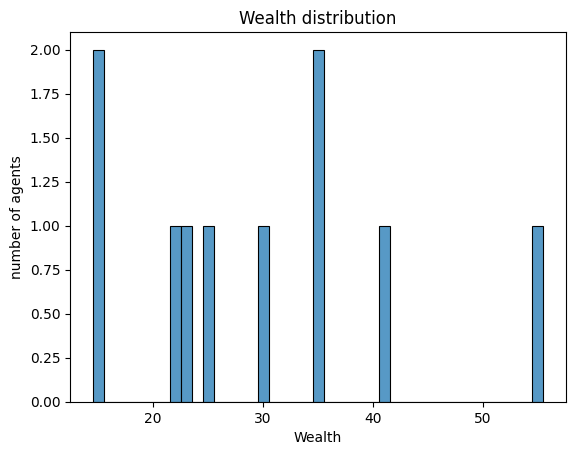

In [ ]:
agent_wealth = [a.wealth for a in model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation

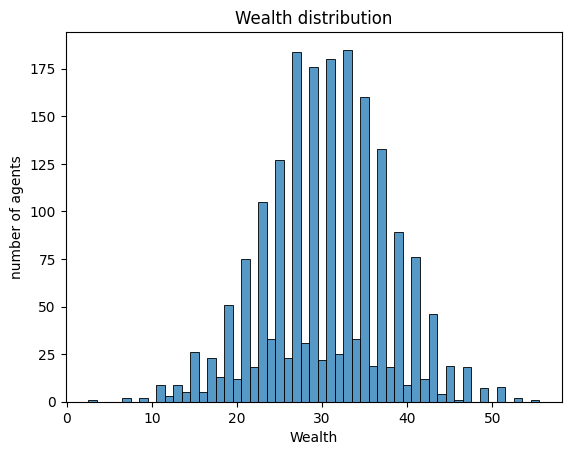

In [ ]:
all_wealth = []
# This runs the model 100 times, each model executing 30 steps.
for _ in range(1000):
    # Run the model
    model = MoneyModel(2)
    model.run_for(30)

    # Store the results
    for agent in model.agents:
        all_wealth.append(agent.wealth)

# Use seaborn
g = sns.histplot(all_wealth, discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

import mesa

In [ ]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth and an ethnicity."""

    def __init__(self, model, ethnicity):
        super().__init__(model)
        self.wealth = 1
        self.ethnicity = ethnicity

    def exchange(self):
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=100):
        super().__init__()
        ethnicities = ["Green", "Blue", "Mixed"]
        MoneyAgent.create_agents(
            model=self,
            n=n,
            ethnicity=self.random.choices(ethnicities, k=n),
        )

    def step(self):
        self.agents.shuffle_do("exchange")

In [ ]:
model = MoneyModel(100)
model.run_for(50)


In [ ]:
# How many agents are in the model?
print(f"Total agents: {len(model.agents)}")

# Iterate over agents (just the first 5 for brevity)
for agent in model.agents.select(at_most=5):
    print(
        f"  Agent {agent.unique_id}: wealth={agent.wealth}, ethnicity={agent.ethnicity}"
    )

Total agents: 100
  Agent 1: wealth=3, ethnicity=Blue
  Agent 2: wealth=0, ethnicity=Mixed
  Agent 3: wealth=0, ethnicity=Blue
  Agent 4: wealth=0, ethnicity=Blue
  Agent 5: wealth=2, ethnicity=Blue


In [ ]:
# Get all wealth values
all_wealth = model.agents.get("wealth")
all_ethin = model.agents.get("ethnicity")
print(all_ethin)
print(f"First 10 wealth values: {all_wealth[:10]}")
print(f"Total wealth in economy: {sum(all_wealth)}")

['Blue', 'Blue', 'Mixed', 'Mixed', 'Mixed', 'Mixed', 'Green', 'Blue', 'Mixed', 'Blue', 'Green', 'Green', 'Green', 'Blue', 'Mixed', 'Blue', 'Blue', 'Green', 'Green', 'Green', 'Blue', 'Green', 'Blue', 'Green', 'Green', 'Mixed', 'Green', 'Mixed', 'Green', 'Green', 'Green', 'Blue', 'Mixed', 'Mixed', 'Green', 'Blue', 'Mixed', 'Green', 'Mixed', 'Green', 'Mixed', 'Green', 'Blue', 'Green', 'Blue', 'Mixed', 'Mixed', 'Blue', 'Mixed', 'Green', 'Green', 'Blue', 'Blue', 'Blue', 'Green', 'Green', 'Mixed', 'Green', 'Blue', 'Blue', 'Blue', 'Blue', 'Green', 'Blue', 'Green', 'Mixed', 'Green', 'Mixed', 'Green', 'Mixed', 'Green', 'Green', 'Blue', 'Mixed', 'Mixed', 'Mixed', 'Mixed', 'Green', 'Blue', 'Mixed', 'Blue', 'Mixed', 'Blue', 'Mixed', 'Mixed', 'Green', 'Blue', 'Blue', 'Green', 'Green', 'Green', 'Green', 'Green', 'Blue', 'Mixed', 'Blue', 'Green', 'Mixed', 'Green', 'Blue']
First 10 wealth values: [0, 0, 2, 1, 0, 2, 0, 0, 2, 1]
Total wealth in economy: 100


In [ ]:
# Get both wealth and ethnicity for each agent
wealth_and_ethnicity = model.agents.get(["wealth", "ethnicity"])
print("First 5 agents (wealth, ethnicity):")
for values in wealth_and_ethnicity[:5]:
    print(f"  {values}")

First 5 agents (wealth, ethnicity):
  [0, 'Blue']
  [0, 'Blue']
  [2, 'Mixed']
  [1, 'Mixed']
  [0, 'Mixed']


In [ ]:
#This would raise AttributeError if any agent lacks 'wealth':
#model.agents.get("nonexistent_attr")

# Safe alternative — returns None for missing attributes:
values = model.agents.get("wh", handle_missing="default", default_value=0)
print(f"Retrieved {len(values)} values safely")

Retrieved 100 values safely


In [ ]:
# Select only wealthy agents (wealth >= 3)
rich_agents = model.agents.select(lambda a: a.wealth >= 3)
print(f"Rich agents (wealth >= 3): {len(rich_agents)}")

# Select agents with no money
broke_agents = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents (wealth == 0): {len(broke_agents)}")

Rich agents (wealth >= 3): 11
Broke agents (wealth == 0): 46


In [ ]:
# In this model we only have one type, but the syntax would be:
money_agents = model.agents.select(agent_type=MoneyAgent)
print(f"MoneyAgents: {len(money_agents)}")




MoneyAgents: 100


In [ ]:
# Get at most 5 rich agents
some_rich = model.agents.select(lambda a: a.wealth >= 2, at_most=5)
print(f"Up to 5 rich agents: {len(some_rich)}")

# Get roughly 10% of agents
ten_percent = model.agents.select(lambda a: a.wealth >=0,at_most=0.9)
print(f"~10% of agents: {len(ten_percent)}")

Up to 5 rich agents: 5
~10% of agents: 90


In [ ]:
# At most 10 MoneyAgents with wealth > 0
subset = model.agents.select(
    filter_func=lambda a: a.wealth > 0,
    agent_type=MoneyAgent,
    at_most=10,
)
print(f"Subset size: {len(subset)}")


Subset size: 10
subste <mesa.agentset.AgentSet object at 0x000001D33D9F9340>


In [ ]:
# Average wealth across all agents
avg_wealth = model.agents.agg("wealth", np.mean)
print(f"Average wealth: {avg_wealth:.2f}")


# Min and max wealth
min_wealth = model.agents.agg("wealth", min)
max_wealth = model.agents.agg("wealth", max)
print(f"Wealth range: {min_wealth} to {max_wealth}")

# Total wealth (should equal the number of agents, since money is conserved)
total = model.agents.agg("wealth", sum)
print(f"Total wealth: {total}")

Average wealth: 1.00
Wealth range: 0 to 5
Total wealth: 100


In [ ]:
min_w, max_w, avg_w = model.agents.agg("wealth", [min, max, np.mean])
print(f"Min: {min_w}, Max: {max_w}, Mean: {avg_w:.2f}")

Min: 0, Max: 5, Mean: 1.00


In [ ]:
# Average wealth of Green agents only
green_avg = model.agents.select(lambda a: a.ethnicity == "Green").agg("wealth", np.mean)
blue_avg = model.agents.select(lambda a: a.ethnicity == "Blue").agg("wealth", np.mean)
mixed_avg = model.agents.select(lambda a: a.ethnicity == "Mixed").agg("wealth", np.mean)

print(
    f"Average wealth — Green: {green_avg:.2f}, Blue: {blue_avg:.2f}, Mixed: {mixed_avg:.2f}"
)

Average wealth — Green: 1.10, Blue: 0.81, Mixed: 1.07


In [ ]:
# Group agents by ethnicity
grouped = model.agents.groupby("ethnicity")

# See how many agents are in each group
print("Agents per ethnicity:", grouped.count())

Agents per ethnicity: {'Blue': 31, 'Mixed': 30, 'Green': 39}


In [ ]:
for ethnicity, group in grouped:
    avg = group.agg("wealth", np.mean)
    print(f"  {ethnicity}: {len(group)} agents, avg wealth = {avg:.2f}")

  Blue: 31 agents, avg wealth = 0.81
  Mixed: 30 agents, avg wealth = 1.07
  Green: 39 agents, avg wealth = 1.10


In [ ]:
# Mean wealth by ethnicity
mean_by_group = grouped.agg("wealth", np.mean)
print("Mean wealth by ethnicity:", mean_by_group)

Mean wealth by ethnicity: {'Blue': np.float64(0.8064516129032258), 'Mixed': np.float64(1.0666666666666667), 'Green': np.float64(1.1025641025641026)}


In [ ]:
# Group agents into wealth brackets
def wealth_bracket(agent):
    if agent.wealth == 0:
        return "broke"
    elif agent.wealth <= 2:
        return "modest"
    else:
        return "wealthy"


brackets = model.agents.groupby(wealth_bracket)
print("Agents per wealth bracket:", brackets.count())

Agents per wealth bracket: {'broke': 46, 'modest': 43, 'wealthy': 11}


In [ ]:
# Give all broke agents a subsidy of 1
broke = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents before subsidy: {len(broke)}")

broke.set("wealth", 1)

# Verify
still_broke = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents after subsidy: {len(still_broke)}")

Broke agents before subsidy: 46
Broke agents after subsidy: 0


In [ ]:
model.agents.select(lambda a: a.wealth > 10).set("taxed", True)


In [ ]:
# Sort by wealth (descending by default)
richest_first = model.agents.sort("wealth")
top_5 = richest_first.select(at_most=5)
print("Top 5 wealthiest agents:")
for agent in top_5:
    print(f"  Agent {agent.unique_id}: wealth={agent.wealth}")

# Sort ascending
poorest_first = model.agents.sort("wealth", ascending=True)
bottom_5 = poorest_first.select(at_most=5)
print("\nBottom 5:")
for agent in bottom_5:
    print(f"  Agent {agent.unique_id}: wealth={agent.wealth}")

Top 5 wealthiest agents:
  Agent 69: wealth=7
  Agent 42: wealth=6
  Agent 25: wealth=4
  Agent 96: wealth=4
  Agent 1: wealth=3

Bottom 5:
  Agent 2: wealth=0
  Agent 3: wealth=0
  Agent 4: wealth=0
  Agent 6: wealth=0
  Agent 7: wealth=0


In [ ]:
agent_list = model.agents.to_list()
print(agent_list)
print(f"First agent: {agent_list[0].unique_id}")
print(f"Last agent: {agent_list[-1].unique_id}")

[<__main__.MoneyAgent object at 0x000001D33F08ED50>, <__main__.MoneyAgent object at 0x000001D33F08CBC0>, <__main__.MoneyAgent object at 0x000001D33F08F770>, <__main__.MoneyAgent object at 0x000001D33F08F890>, <__main__.MoneyAgent object at 0x000001D33F08E450>, <__main__.MoneyAgent object at 0x000001D33F08D5E0>, <__main__.MoneyAgent object at 0x000001D33F08E210>, <__main__.MoneyAgent object at 0x000001D33F08DBE0>, <__main__.MoneyAgent object at 0x000001D33F08FA10>, <__main__.MoneyAgent object at 0x000001D33F08D610>, <__main__.MoneyAgent object at 0x000001D33F08C560>, <__main__.MoneyAgent object at 0x000001D33F08D580>, <__main__.MoneyAgent object at 0x000001D33F08C9E0>, <__main__.MoneyAgent object at 0x000001D33F08E600>, <__main__.MoneyAgent object at 0x000001D33F08EC60>, <__main__.MoneyAgent object at 0x000001D33F08FDD0>, <__main__.MoneyAgent object at 0x000001D33F08D250>, <__main__.MoneyAgent object at 0x000001D33F08D9D0>, <__main__.MoneyAgent object at 0x000001D33F08DD00>, <__main__.M

In [ ]:
print("=== Model Summary After 50 Steps ===\n")

# Overall statistics
min_w, max_w, avg_w, total_w = model.agents.agg("wealth", [min, max, np.mean, sum])
print(f"Agents: {len(model.agents)}")
print(
    f"Total wealth: {total_w} (conserved: {'yes' if total_w == len(model.agents) else 'no, subsidy applied'})"
)
print(f"Wealth range: {min_w} to {max_w}, mean: {avg_w:.2f}\n")

# By ethnicity
print("By ethnicity:")
for ethnicity, group in model.agents.groupby("ethnicity"):
    count = len(group)
    avg = group.agg("wealth", np.mean)
    broke = len(group.select(lambda a: a.wealth == 0))
    print(
        f"  {ethnicity:6s}: {count:3d} agents, avg wealth = {avg:.2f}, broke = {broke}"
    )

# Wealth distribution
print("\nWealth brackets:")
for bracket, group in model.agents.groupby(wealth_bracket):
    print(f"  {bracket:8s}: {len(group)} agents")

=== Model Summary After 50 Steps ===

Agents: 100
Total wealth: 100 (conserved: yes)
Wealth range: 0 to 7, mean: 1.00

By ethnicity:
  Blue  :  37 agents, avg wealth = 0.76, broke = 23
  Mixed :  36 agents, avg wealth = 1.08, broke = 16
  Green :  27 agents, avg wealth = 1.22, broke = 11

Wealth brackets:
  wealthy : 14 agents
  broke   : 50 agents
  modest  : 36 agents


[Text(0.5, 1.0, 'Wealth distribution by ethnicity'),
 Text(0.5, 0, 'Wealth'),
 Text(0, 0.5, 'Number of agents')]

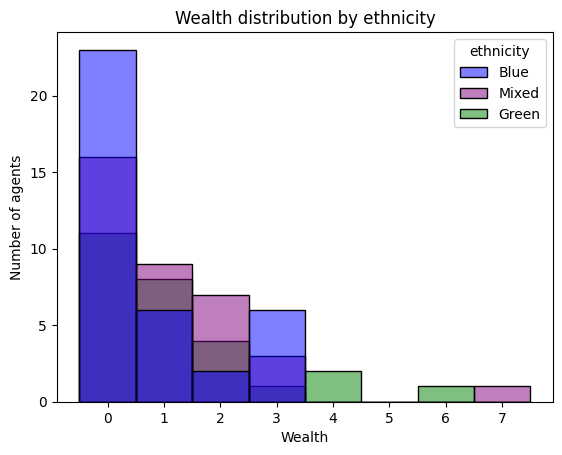

In [ ]:
# Collect data for plotting
data = []
for agent in model.agents:
    data.append({"wealth": agent.wealth, "ethnicity": agent.ethnicity})
df = pd.DataFrame(data)

palette = {"Green": "green", "Blue": "blue", "Mixed": "purple"}
g = sns.histplot(data=df, x="wealth", hue="ethnicity", discrete=True, palette=palette)
g.set(
    title="Wealth distribution by ethnicity", xlabel="Wealth", ylabel="Number of agents"
)

In [208]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    def exchange(self):
        if self.wealth > 0:
                
            other = self.random.choice(self.model.agents)
            other.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10):
        super().__init__()
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        # Random activation — each agent acts in a random order
        self.agents.shuffle_do("exchange")

In [209]:
model = MoneyModel(10)
model.run_for(30)

wealth = model.agents.get("wealth")
# id = model.agents.get("unique_id")
# print(id)


print(f"Wealth distribution: {wealth }")
print(f"Total wealth: {sum(wealth)} (should be {len(model.agents)})")

Wealth distribution: [0, 0, 0, 6, 0, 0, 0, 1, 0, 3]
Total wealth: 10 (should be 10)


In [210]:

# Fixed order — same agent always goes first
class FixedOrderModel(mesa.Model):
    def __init__(self, n=10):
        super().__init__()
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        self.agents.do("exchange")  # Same order every step


# Random order — different every step
class RandomOrderModel(mesa.Model):
    def __init__(self, n=10):
        super().__init__()
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        self.agents.shuffle_do("exchange")


# Run both multiple times and compare Gini coefficients
def gini(model):
    x = sorted(model.agents.get("wealth"))
    n = len(x)
    B = sum(xi * (n - i) for i, xi in enumerate(x)) / (n * sum(x))
    return 1 + (1 / n) - 2 * B


fixed_ginis = []
random_ginis = []
for _ in range(50):
    m = FixedOrderModel(50)
    m.run_for(100)
    fixed_ginis.append(gini(m))

    m = RandomOrderModel(50)
    m.run_for(100)
    random_ginis.append(gini(m))

print(
    f"Fixed order  — mean Gini: {np.mean(fixed_ginis):.3f} (std: {np.std(fixed_ginis):.3f})"
)
print(
    f"Random order — mean Gini: {np.mean(random_ginis):.3f} (std: {np.std(random_ginis):.3f})"
)




Fixed order  — mean Gini: 0.628 (std: 0.048)
Random order — mean Gini: 0.625 (std: 0.040)


In [211]:
# Using a callable instead of a method name
def tax_agent(agent):
    """Take 10% tax from agents with wealth > 5."""
    if agent.wealth > 5:
        tax = agent.wealth // 10
        agent.wealth -= tax


model = MoneyModel(50)
model.run_for(100)

print(f"Max wealth before tax: {model.agents.agg('wealth', max)}")
model.agents.do(tax_agent)
print(f"Max wealth after tax: {model.agents.agg('wealth', max)}")

Max wealth before tax: 4
Max wealth after tax: 4


In [213]:
class ReportingAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1
        self.age = self.random.randint(18, 80)

    def report_status(self):
        return {"id": self.unique_id, "wealth": self.wealth, "age": self.age}

    def exchange(self):
        if self.wealth > 0:
            other = self.random.choice(self.model.agents)
            other.wealth += 1
            self.wealth -= 1


class ReportingModel(mesa.Model):
    def __init__(self, n=10):
        super().__init__()
        ReportingAgent.create_agents(model=self, n=n)

    def step(self):
        self.agents.shuffle_do("exchange")


model = ReportingModel(10)
model.run_for(20)

# Collect status reports from all agents
reports = model.agents.map("report_status")
print("Agent reports:")
for r in reports:
    print(f"  {r}")

Agent reports:
  {'id': 1, 'wealth': 3, 'age': 27}
  {'id': 2, 'wealth': 1, 'age': 26}
  {'id': 3, 'wealth': 0, 'age': 75}
  {'id': 4, 'wealth': 0, 'age': 41}
  {'id': 5, 'wealth': 1, 'age': 63}
  {'id': 6, 'wealth': 1, 'age': 33}
  {'id': 7, 'wealth': 3, 'age': 23}
  {'id': 8, 'wealth': 1, 'age': 79}
  {'id': 9, 'wealth': 0, 'age': 58}
  {'id': 10, 'wealth': 0, 'age': 28}


In [ ]:
# Calculate each agent's wealth-to-age ratio
ratios = model.agents.map(lambda a: a.wealth / a.age)
print(f"Wealth/age ratios (first 5): {[f'{r:.3f}' for r in ratios[:5]]}")

Wealth/age ratios (first 5): ['0.111', '0.038', '0.000', '0.000', '0.016', '0.030', '0.130', '0.013', '0.000', '0.000']


In [221]:
class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    def exchange(self):
        if self.wealth > 0:
            other = self.random.choice(self.model.agents)
            other.wealth += 1
            self.wealth -= 1

    def donate(self, recipients):
        """Give 1 unit to a random recipient."""
        if self.wealth > 0 and len(recipients) > 0:
            recipient = self.random.choice(recipients)
            recipient.wealth += 1
            self.wealth -= 1


class PolicyModel(mesa.Model):
    """A model where only rich agents donate to poor agents."""

    def __init__(self, n=100):
        super().__init__()
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        # First: normal exchanges
        self.agents.shuffle_do("exchange")

        # Then: redistribution policy — rich donate to poor
        rich = self.agents.select(lambda a: a.wealth >= 5)
        poor = self.agents.select(lambda a: a.wealth == 0)
        if len(rich) > 0 and len(poor) > 0:
            rich.shuffle_do("donate", poor)


model = PolicyModel(100)
model.run_for(100)

broke = len(model.agents.select(lambda a: a.wealth == 0))
rich = len(model.agents.select(lambda a: a.wealth >= 5))
print(f"After redistribution policy: {broke} broke agents, {rich} rich agents")

After redistribution policy: 40 broke agents, 0 rich agents


In [222]:
class Prey(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.energy = 5

    def move(self):
        self.energy -= 1

    def eat(self):
        self.energy += self.random.randint(0, 2)

    def reproduce(self):
        if self.energy > 8:
            self.energy -= 4
            Prey(self.model)  # New prey is automatically registered


class Predator(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.energy = 10
        self.kills = 0

    def move(self):
        self.energy -= 2  # Predators use more energy

    def hunt(self):
        prey_agents = self.model.agents_by_type.get(Prey)
        if prey_agents and len(prey_agents) > 0 and self.energy > 0:
            target = self.random.choice(prey_agents)
            target.remove()
            self.energy += 5
            self.kills += 1


class EcosystemModel(mesa.Model):
    def __init__(self, n_prey=50, n_predators=5):
        super().__init__()
        Prey.create_agents(model=self, n=n_prey)
        Predator.create_agents(model=self, n=n_predators)

    def step(self):
        # Stage 1: All agents move (random order within each type)
        for agent_type in self.agent_types:
            self.agents_by_type[agent_type].shuffle_do("move")

        # Stage 2: Type-specific actions
        if Prey in self.agents_by_type:
            self.agents_by_type[Prey].shuffle_do("eat")
        if Predator in self.agents_by_type:
            self.agents_by_type[Predator].shuffle_do("hunt")

        # Stage 3: Only prey with enough energy reproduce
        if Prey in self.agents_by_type:
            fertile = self.agents_by_type[Prey].select(lambda a: a.energy > 8)
            fertile.do("reproduce")

        # Remove dead agents (energy depleted)
        dead = self.agents.select(lambda a: a.energy <= 0)
        for agent in dead:
            agent.remove()


eco = EcosystemModel(50, 5)
eco.run_for(20)

n_prey = len(eco.agents_by_type.get(Prey, []))
n_pred = len(eco.agents_by_type.get(Predator, []))
print(f"After 20 steps: {n_prey} prey, {n_pred} predators, {len(eco.agents)} total")

After 20 steps: 0 prey, 5 predators, 5 total


In [223]:
from mesa.time import Priority, Schedule


In [243]:
class SimpleModel(mesa.Model):
    def __init__(self):
        super().__init__()
        self.steps = 0

    def step(self):
        print(f"  Step {self.steps} at time {self.time:.1f}")


model = SimpleModel()

print("Initial state:")
print(f"  steps={model.steps}, time={model.time}")
print("\nRunning for 3 time units:")
model.run_for(3)
print(f"\nFinal state: steps={model.steps}, time={model.time}")




Initial state:
  steps=0, time=0.0

Running for 3 time units:
  Step 1 at time 1.0
  Step 2 at time 2.0
  Step 3 at time 3.0

Final state: steps=3, time=3.0


In [244]:
model = SimpleModel()

print("run_for(2):")
model.run_for(2)
print(f"  → time is now {model.time}\n")

print("run_until(5):")
model.run_until(5)
print(f"  → time is now {model.time}\n")

print("run_for(3) more:")
model.run_for(3)
print(f"  → time is now {model.time}")

run_for(2):
  Step 1 at time 1.0
  Step 2 at time 2.0
  → time is now 2.0

run_until(5):
  Step 3 at time 3.0
  Step 4 at time 4.0
  Step 5 at time 5.0
  → time is now 5

run_for(3) more:
  Step 6 at time 6.0
  Step 7 at time 7.0
  Step 8 at time 8.0
  → time is now 8


In [258]:
class EconomyModel(mesa.Model):
    """A simple economy where a tax reform happens at a specific time."""

    def __init__(self, n=50):
        super().__init__()
        self.tax_rate = 0.1
        self.events_log = []

        # Create agents with wealth
        for _ in range(n):
            a = mesa.Agent(self)
            a.wealth = 10

        # Schedule a tax reform at time 5.0
        self.schedule_event(self.check, at = 3.0)

        self.schedule_event(self.tax_reform, at=5.0)

        # Schedule a stimulus check 2 time units from now (so at time 2.0)
        self.schedule_event(self.stimulus, after=2.0)
        

    def tax_reform(self):
        self.tax_rate = 0.25
        self.events_log.append(
            f"t={self.time:.1f}: Tax reform! Rate now {self.tax_rate}"
        )

    def stimulus(self):
        for agent in self.agents:
            agent.wealth += 5
            print(f"stimulus {agent.wealth}")
        self.events_log.append(f"t={self.time:.1f}: Stimulus! Everyone gets 5 units")

    def step(self):
        # Simple taxation each step
        for agent in self.agents:
            tax = int(agent.wealth * self.tax_rate)
            agent.wealth -= tax
        
    def check(self):
        for agent in self.agents:
            print(agent.wealth)


model = EconomyModel(10)
model.run_for(7)

print("Events that occurred:")
for event in model.events_log:
    print(f"  {event}")

print(f"\nFinal tax rate: {model.tax_rate}")
avg_wealth = model.agents.agg("wealth", np.mean)
print(f"Average wealth: {avg_wealth:.1f}")

stimulus 14
stimulus 14
stimulus 14
stimulus 14
stimulus 14
stimulus 14
stimulus 14
stimulus 14
stimulus 14
stimulus 14
13
13
13
13
13
13
13
13
13
13
Events that occurred:
  t=2.0: Stimulus! Everyone gets 5 units
  t=5.0: Tax reform! Rate now 0.25

Final tax rate: 0.25
Average wealth: 7.0


In [259]:
class CancelDemo(mesa.Model):
    def __init__(self):
        super().__init__()

        # Schedule two events
        self.event_a = self.schedule_event(self.event_a_fn, at=3.0)
        self.event_b = self.schedule_event(self.event_b_fn, at=5.0)

        # Cancel event B before it fires
        self.event_b.cancel()

    def event_a_fn(self):
        print(f"  Event A fired at t={self.time:.1f}")

    def event_b_fn(self):
        print(f"  Event B fired at t={self.time:.1f}")

    def step(self):
        pass


model = CancelDemo()
print("Running — Event B was canceled:")
model.run_for(6)
print("  (Event B never fired)")

Running — Event B was canceled:
  Event A fired at t=3.0
  (Event B never fired)


In [263]:
class SeasonalModel(mesa.Model):
    """A model with regular seasonal events."""

    def __init__(self, n=20):
        super().__init__()
        self.season = "spring"
        self.season_log = []

        for _ in range(n):
            a = mesa.Agent(self)
            a.wealth = 10

        # Change season every 3 time units, starting at t=3.0
        self.schedule_recurring(
            self.change_season,
            Schedule(interval=3.0),
        )

        # Collect taxes every 5 time units, but only 4 times
        self.schedule_recurring(
            self.collect_taxes,
            Schedule(interval=5.0, count=4),
        )

    def change_season(self):
        seasons = ["spring", "summer", "autumn", "winter"]
        idx = seasons.index(self.season)
        self.season = seasons[(idx + 1) % 4]
        self.season_log.append(f"t={self.time:.1f}: Season → {self.season}")

    def collect_taxes(self):
        for agent in self.agents:
            agent.wealth -= 1
        self.season_log.append(f"t={self.time:.1f}: Taxes collected!")

    def step(self):
        # Normal step — agents earn money
        for agent in self.agents:
            agent.wealth += self.random.randint(0, 2)


model = SeasonalModel(10)
model.run_for(20)

print("Timeline:")
for entry in model.season_log:
    print(f"  {entry}")
print(f"\nFinal season: {model.season}")
print(f"Average wealth: {model.agents.agg('wealth', np.mean):.1f}")

Timeline:
  t=3.0: Season → summer
  t=5.0: Taxes collected!
  t=6.0: Season → autumn
  t=9.0: Season → winter
  t=10.0: Taxes collected!
  t=12.0: Season → spring
  t=15.0: Taxes collected!
  t=15.0: Season → summer
  t=18.0: Season → autumn
  t=20.0: Taxes collected!

Final season: autumn
Average wealth: 25.3


In [264]:
class StartDemo(mesa.Model):
    def __init__(self):
        super().__init__()

        # Fires at t=5, t=10, t=15, ... (default start)
        self.schedule_recurring(
            self.default_start_event,
            Schedule(interval=5.0),
        )

        # Fires at t=0, t=5, t=10, ... (start immediately)
        self.schedule_recurring(
            self.start_at_zero_event,
            Schedule(interval=5.0, start=0.0),
        )

        # Fires at t=2, t=7, t=12, ... (custom start)
        self.schedule_recurring(
            self.start_at_two_event,
            Schedule(interval=5.0, start=2.0),
        )

    def default_start_event(self):
        print(f"  Default start: t={self.time:.1f}")

    def start_at_zero_event(self):
        print(f"  Start at 0:    t={self.time:.1f}")

    def start_at_two_event(self):
        print(f"  Start at 2:    t={self.time:.1f}")

    def step(self):
        pass


model = StartDemo()
print("Events firing during first 12 time units:")
model.run_for(12)

Events firing during first 12 time units:
  Start at 0:    t=0.0
  Start at 2:    t=2.0
  Default start: t=5.0
  Start at 0:    t=5.0
  Start at 2:    t=7.0
  Default start: t=10.0
  Start at 0:    t=10.0
  Start at 2:    t=12.0


In [265]:
class StopDemo(mesa.Model):
    def __init__(self):
        super().__init__()
        self.counter = 0

        # Start a recurring event
        self.ticker = self.schedule_recurring(
            self.tick,
            Schedule(interval=1.0),
        )

    def tick(self):
        self.counter += 1
        print(f"  Tick #{self.counter} at t={self.time:.1f}")

    def step(self):
        # Stop the ticker after 5 ticks
        if self.counter >= 5 and self.ticker.is_active:
            self.ticker.stop()
            print(f"  Ticker stopped at t={self.time:.1f}")


model = StopDemo()
model.run_for(10)
print(f"\nTotal ticks: {model.counter}")

  Tick #1 at t=1.0
  Tick #2 at t=2.0
  Tick #3 at t=3.0
  Tick #4 at t=4.0
  Tick #5 at t=5.0
  Ticker stopped at t=6.0

Total ticks: 5


In [266]:
# Stop after time 50.0
Schedule(interval=5.0, end=50.0)
# Execute at most 10 times
Schedule(interval=5.0, count=10)
# Both: stop after 10 executions OR after time 50.0, whichever comes first
Schedule(interval=5.0, count=10, end=50.0)

Schedule(interval=5.0, start=None, end=50.0, count=10)

In [268]:
class AcceleratingModel(mesa.Model):
    """A model where events happen faster and faster."""

    def __init__(self):
        super().__init__()
        self.event_times = []

        # Interval starts at 4.0 and shrinks each time
        self.schedule_recurring(
            self.record_event,
            Schedule(
                interval = lambda m: max(1.0, 4.0 - m.time * 0.3),
                count=8,
            ),
        )

    def record_event(self):
        self.event_times.append(self.time)

    def step(self):
        pass


model = AcceleratingModel()
model.run_for(25)

print("Event times (accelerating intervals):")
for i, t in enumerate(model.event_times):
    if i > 0:
        gap = t - model.event_times[i - 1]
        print(f"  t = {t:.1f} (gap: {gap:.1f})")
    else:
        print(f"  t={t:.1f}")

Event times (accelerating intervals):
  t=4.0
  t = 6.8 (gap: 2.8)
  t = 8.8 (gap: 2.0)
  t = 10.1 (gap: 1.4)
  t = 11.1 (gap: 1.0)
  t = 12.1 (gap: 1.0)
  t = 13.1 (gap: 1.0)
  t = 14.1 (gap: 1.0)


In [269]:
class PriorityDemo(mesa.Model):
    def __init__(self):
        super().__init__()

        # Schedule three events at the same time with different priorities
        self.schedule_event(
            self.low_priority_event,
            at=2.0,
            priority=Priority.LOW,
        )
        self.schedule_event(
            self.high_priority_event,
            at=2.0,
            priority=Priority.HIGH,
        )
        self.schedule_event(
            self.default_priority_event,
            at=2.0,
            priority=Priority.DEFAULT,
        )

    def low_priority_event(self):
        print(f"  LOW priority event at t={self.time:.1f}")

    def high_priority_event(self):
        print(f"  HIGH priority event at t={self.time:.1f}")

    def default_priority_event(self):
        print(f"  DEFAULT priority event at t={self.time:.1f}")

    def step(self):
        if self.time == 2.0:
            print(f"  Model step (HIGH priority) at t={self.time:.1f}")


model = PriorityDemo()
print("Events at t=2.0 in execution order:")
model.run_for(3)

Events at t=2.0 in execution order:
  HIGH priority event at t=2.0
  Model step (HIGH priority) at t=2.0
  DEFAULT priority event at t=2.0
  LOW priority event at t=2.0


In [270]:
class Citizen(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 10
        self.savings = 0

    def exchange(self):
        """Give 1 unit to a random other agent."""
        if self.wealth > 0:
            other = self.random.choice(self.model.agents)
            other.wealth += 1
            self.wealth -= 1

    def earn_interest(self):
        """Earn interest on savings based on current rate."""
        interest = int(self.savings * self.model.interest_rate)
        self.savings += interest


class CentralBankModel(mesa.Model):
    """An economy with monetary policy events."""

    def __init__(self, n_citizens=50):
        super().__init__()
        self.interest_rate = 0.05
        self.log = []

        Citizen.create_agents(model=self, n=n_citizens)

        # Distribute initial savings randomly
        for agent in self.agents:
            agent.savings = self.random.randint(0, 20)

        # Recurring: Central bank reviews interest rate every 10 time units
        self.rate_review = self.schedule_recurring(
            self.review_interest_rate,
            Schedule(interval=10.0, start=10.0),
        )

        # Recurring: Interest is paid every 5 time units
        self.schedule_recurring(
            self.pay_interest,
            Schedule(interval=5.0),
        )

        # One-off: Economic stimulus at t=25
        self.schedule_event(self.economic_stimulus, at=25.0)

    def review_interest_rate(self):
        """Central bank adjusts rate based on average wealth."""
        avg_wealth = self.agents.agg("wealth", np.mean)
        if avg_wealth < 8:
            self.interest_rate = min(0.15, self.interest_rate + 0.02)
            action = "raised"
        elif avg_wealth > 12:
            self.interest_rate = max(0.01, self.interest_rate - 0.02)
            action = "lowered"
        else:
            action = "held"
        self.log.append(
            f"t={self.time:5.1f} | Rate review: {action} to {self.interest_rate:.0%} "
            f"(avg wealth: {avg_wealth:.1f})"
        )

    def pay_interest(self):
        """Pay interest to all citizens."""
        total_paid = 0
        for agent in self.agents:
            interest = int(agent.savings * self.interest_rate)
            agent.savings += interest
            total_paid += interest
        self.log.append(f"t={self.time:5.1f} | Interest paid: {total_paid} total")

    def economic_stimulus(self):
        """One-time stimulus: every citizen gets 5 units."""
        for agent in self.agents:
            agent.wealth += 5
        self.log.append(f"t={self.time:5.1f} | *** STIMULUS: +5 to all citizens ***")

    def step(self):
        """Regular step: agents exchange money."""
        self.agents.shuffle_do("exchange")

        # Some agents save a portion of their wealth
        for agent in self.agents.select(lambda a: a.wealth > 3):
            save_amount = agent.wealth // 4
            agent.wealth -= save_amount
            agent.savings += save_amount


# Run the simulation
model = CentralBankModel(50)
model.run_until(50)

print("=== Central Bank Economy: Event Log ===\n")
for entry in model.log:
    print(f"  {entry}")

print(f"\n=== Final State (t={model.time:.0f}) ===")
print(f"Interest rate: {model.interest_rate:.0%}")
print(f"Avg wealth: {model.agents.agg('wealth', np.mean):.1f}")
print(f"Avg savings: {model.agents.agg('savings', np.mean):.1f}")
total = sum(a.wealth + a.savings for a in model.agents)
print(f"Total money in economy: {total}")

=== Central Bank Economy: Event Log ===

  t=  5.0 | Interest paid: 21 total
  t= 10.0 | Rate review: raised to 7% (avg wealth: 2.0)
  t= 10.0 | Interest paid: 35 total
  t= 15.0 | Interest paid: 42 total
  t= 20.0 | Rate review: raised to 9% (avg wealth: 1.1)
  t= 20.0 | Interest paid: 71 total
  t= 25.0 | *** STIMULUS: +5 to all citizens ***
  t= 25.0 | Interest paid: 75 total
  t= 30.0 | Rate review: raised to 11% (avg wealth: 2.5)
  t= 30.0 | Interest paid: 129 total
  t= 35.0 | Interest paid: 142 total
  t= 40.0 | Rate review: raised to 13% (avg wealth: 1.3)
  t= 40.0 | Interest paid: 199 total
  t= 45.0 | Interest paid: 227 total
  t= 50.0 | Rate review: raised to 15% (avg wealth: 0.9)
  t= 50.0 | Interest paid: 302 total

=== Final State (t=50) ===
Interest rate: 15%
Avg wealth: 0.9
Avg savings: 49.5
Total money in economy: 2518


# ADDING SPACE


In [275]:
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa


In [276]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n

        # Create agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter
        self.agents.shuffle_do("exchange")

In [277]:
# Execute the model
model = MoneyModel(10)
model.step()
# Make sure it worked
print(f"You have {len(model.agents)} agents.")

You have 10 agents.


In [302]:
# Import Cell Agent and OrthogonalMooreGrid
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid


# Instantiate MoneyAgent as CellAgent
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1

    # Move Function
    def move(self):
        # cellules voisines avec place dispo
        available = self.cell.neighborhood.select(lambda c: len(c.agents) < c.capacity)
        # si au moins une cellule a de la place, on en prend une aléatoire via Mesa
        if len(available) > 0:
            self.cell = available.select_random_cell()

    def give_money(self):
        cellmates = [a for a in self.cell.agents if a is not self]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, width, height, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        # Instantiate an instance of Moore neighborhood space
        self.grid = OrthogonalMooreGrid((width, height), torus=True, random=self.random, capacity = 5)
        
        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

In [303]:
model = MoneyModel(100, 10, 10,5)
for _ in range(20):
    model.step()

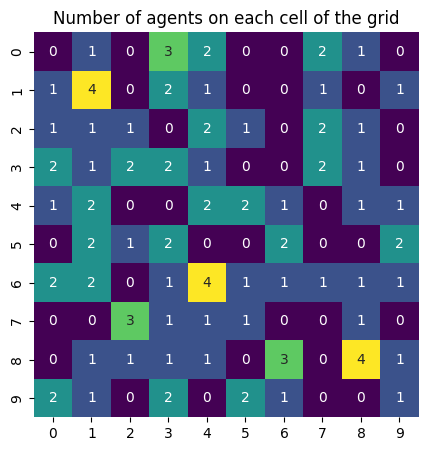

In [304]:
agent_counts = np.zeros((model.grid.width, model.grid.height))

for cell in model.grid.all_cells:
    agent_counts[cell.coordinate] = len(cell.agents)
# Plot using seaborn, with a visual size of 5x5
g = sns.heatmap(agent_counts, cmap="viridis", annot=True, cbar=False, square=True)
g.figure.set_size_inches(5, 5)
g.set(title="Number of agents on each cell of the grid");

In [333]:
# Import Cell Agent and OrthogonalMooreGrid
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid, OrthogonalVonNeumannGrid,VoronoiGrid


# Instantiate MoneyAgent as CellAgent
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1

    # Move Function
    # Move Function
    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        cellmates = [a for a in self.cell.agents if a is not self]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n,centroids, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        # Instantiate an instance of Moore neighborhood space
        self.grid = VoronoiGrid(centroids_coordinates=centroids, random=self.random)
        
        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

In [346]:
centroids = [[0, 0], [1, 0], [0, 1], [1, 1], [0.4, 0.7], [0.8, 0.2]]
model = MoneyModel(3, centroids)
for _ in range(20):
    model.step()

max = max 

C:\Users\ouahi\AppData\Local\Temp\ipykernel_15056\3308840249.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(x_coords, y_coords,


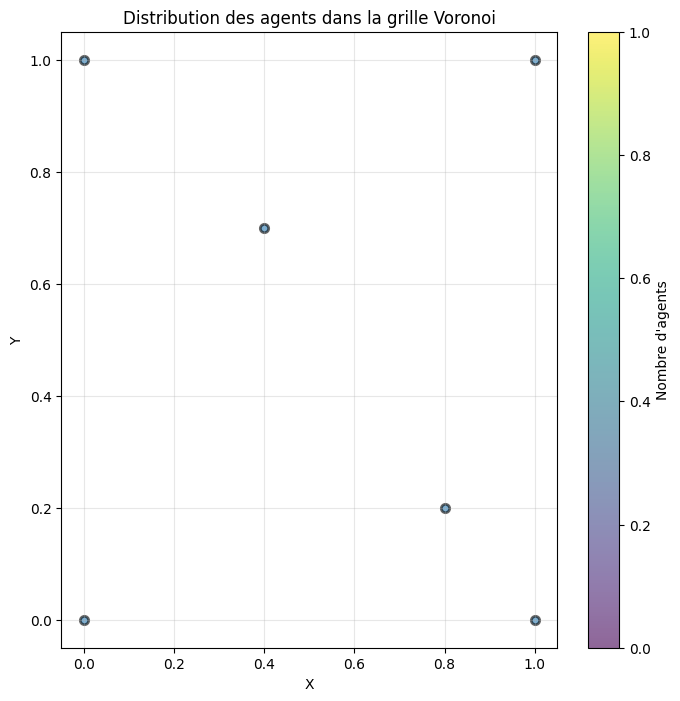

In [ ]:
import matplotlib.pyplot as plt
agent_per_cell = [len(cell.agents) for cell in model.grid.all_cells.cells]

x_coords = [c[0] for c in centroids]
y_coords = [c[1] for c in centroids]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(x_coords, y_coords, # couleur = nombre d'agents
                     cmap="viridis",        # dégradé de couleur
                     alpha=0.6,             # transparence
                     edgecolors='black',    # bordure noire
                     linewidth=2)

plt.colorbar(scatter, label="Nombre d'agents")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Distribution des agents dans la grille Voronoi")
plt.grid(True, alpha=0.3)
plt.show()

# Collecting Data


In [350]:
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid


In [378]:
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1

    # Move Function
    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        cellmates = [
            a for a in self.cell.agents if a is not self
        ]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, width, height, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        # Instantiate an instance of Moore neighborhood space
        self.grid = OrthogonalMooreGrid((width, height), torus=True, random=self.random)

        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

In [379]:
model = MoneyModel(100, 10, 10)
model.run_for(20)
# Let's make sure it worked
print(len(model.agents))

100


In [380]:
# Add function for model level collection
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    n = model.num_agents
    B = sum(xi * (n - i) for i, xi in enumerate(x)) / (n * sum(x))
    return 1 + (1 / n) - 2 * B


class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell
        self.wealth = 1

    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        cellmates = [a for a in self.cell.agents if a is not self]

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, width, height, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        self.grid = OrthogonalMooreGrid((width, height), torus=True, random=self.random)
        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, agent_reporters={"Wealth": "wealth"}
        )

        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        # Collect data each step
        self.datacollector.collect(self)
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

In [381]:
model = MoneyModel(100, 10, 10)
model.run_for(100)

,Gini
0,0.0000
1,0.1800
...,...
98,0.4750
99,0.4798


[Text(0.5, 1.0, 'Gini Coefficient over Time'),
 Text(0, 0.5, 'Gini Coefficient')]

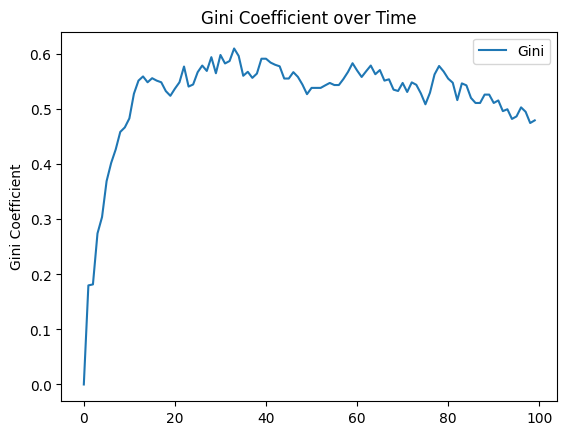

In [382]:
# Extract MoneyModel data in a Pandas dataframe
gini = model.datacollector.get_model_vars_dataframe()

display(gini)
g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient")

In [383]:
pd.set_option('display.max_rows', 5)


In [384]:
# Extract MoneyAgent data in a Pandas dataframe
agent_wealth = model.datacollector.get_agent_vars_dataframe()
display(agent_wealth)

Wealth
Step  AgentID        
1.0   1             1
      2             1
...               ...
100.0 99            0
      100           0

[10000 rows x 1 columns]

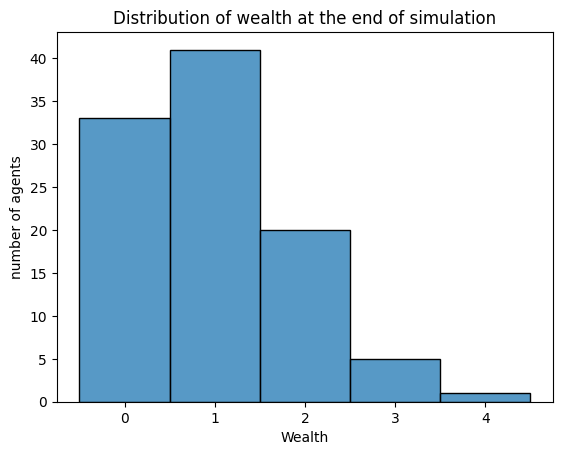

In [385]:
last_step = agent_wealth.index.get_level_values("Step").max()  # Get the last step
end_wealth = agent_wealth.xs(last_step, level="Step")[
    "Wealth"
]  # Get the wealth of each agent at the last step
# Create a histogram of wealth at the last step
g = sns.histplot(end_wealth, discrete=True)
g.set(
    title="Distribution of wealth at the end of simulation",
    xlabel="Wealth",
    ylabel="number of agents",
);

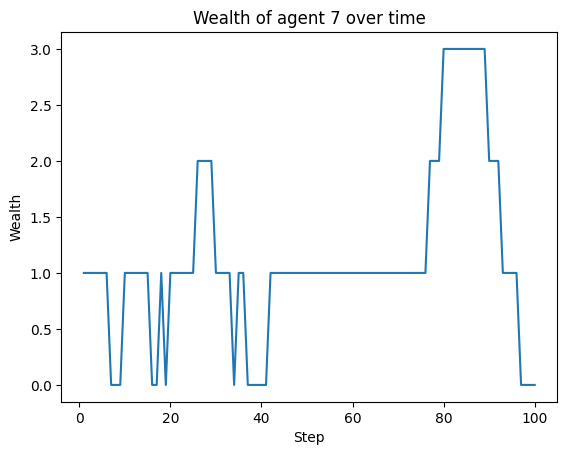

In [386]:
# Get the wealth of agent 7 over time
one_agent_wealth = agent_wealth.xs(7, level="AgentID")

# Plot the wealth of agent 7 over time
g = sns.lineplot(data=one_agent_wealth, x="Step", y="Wealth")
g.set(title="Wealth of agent 7 over time");

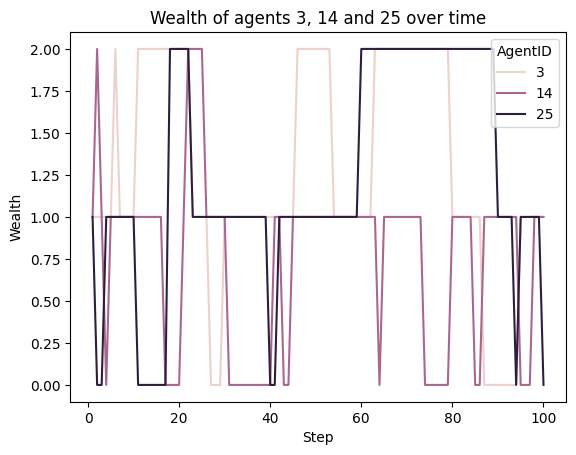

In [387]:
agent_list = [3, 14, 25]

# Get the wealth of multiple agents over time
multiple_agents_wealth = agent_wealth[
    agent_wealth.index.get_level_values("AgentID").isin(agent_list)
]
# Plot the wealth of multiple agents over time
g = sns.lineplot(data=multiple_agents_wealth, x="Step", y="Wealth", hue="AgentID")
g.set(title="Wealth of agents 3, 14 and 25 over time");

[Text(0.5, 1.0, 'Average wealth over time')]

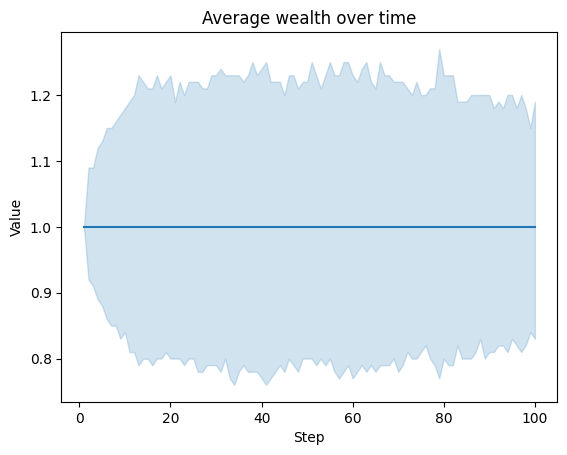

In [388]:
# Transform the data to a long format
agent_wealth_long = agent_wealth.T.unstack().reset_index()
agent_wealth_long.columns = ["Step", "AgentID", "Variable", "Value"]
agent_wealth_long.head(3)

# Plot the average wealth over time
g = sns.lineplot(data=agent_wealth_long, x="Step", y="Value", errorbar=("ci", 95))
g.set(title="Average wealth over time")

In [389]:
# save the model data (stored in the pandas gini object) to CSV
gini.to_csv("model_data.csv")

# save the agent data (stored in the pandas agent_wealth object) to CSV
agent_wealth.to_csv("agent_data.csv")

# Visualization basics 


In [390]:
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid

# Check Mesa version for visualization compatibility
if mesa.__version__.startswith(("3.0", "3.1", "3.2")):
    print(
        f"⚠️  Mesa {mesa.__version__} detected. Visualization features require Mesa 3.3+"
    )
    print("To upgrade: pip install --upgrade mesa")

from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa.visualization.components import AgentPortrayalStyle

In [394]:
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    N = model.num_agents
    B = sum(xi * (N - i) for i, xi in enumerate(x)) / (N * sum(x))
    return 1 + (1 / N) - 2 * B


class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        """initialize a MoneyAgent instance.

        Args:
            model: A model instance
        """
        super().__init__(model)
        self.cell = cell
        self.wealth = 1

    def move(self):
        """Move the agent to a random neighboring cell."""
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        """Give 1 unit of wealth to a random agent in the same cell."""
        cellmates = [a for a in self.cell.agents if a is not self]

        if cellmates:  # Only give money if there are other agents present
            other = self.random.choice(cellmates)
            other.wealth += 1
            self.wealth -= 1

    def step(self):
        """do one step of the agent."""
        self.move()
        if self.wealth > 0:
            self.give_money()


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, width=10, height=10, rng=None):
        """Initialize a MoneyModel instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(rng=rng)
        self.num_agents = n
        self.grid = OrthogonalMooreGrid((width, height), random=self.random)

        # Create agents
        MoneyAgent.create_agents(
            self,
            self.num_agents,
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, agent_reporters={"Wealth": "wealth"}
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

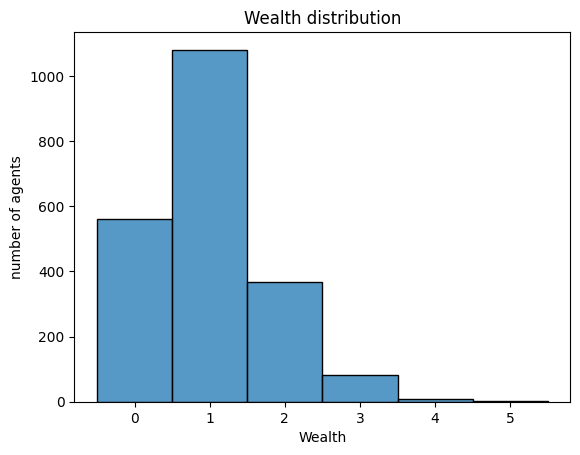

In [395]:
# Lets make sure the model works
model = MoneyModel(n=100, width=100, height=10, rng=10)
model.run_for(20)


data = model.datacollector.get_agent_vars_dataframe()
# Use seaborn
g = sns.histplot(data["Wealth"], discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

In [397]:
def agent_portrayal(agent):
    return AgentPortrayalStyle(color="tab:orange", size=50)

In [398]:
model_params = {
    "n": {
        "type": "SliderInt",
        "value": 50,
        "label": "Number of agents:",
        "min": 10,
        "max": 100,
        "step": 1,
    },
    "width": 10,
    "height": 10,
}

In [399]:
plot_comp = make_plot_component("encoding", page=1)


In [401]:
# Create initial model instance
money_model = MoneyModel(n=50, width=10, height=10)  # keyword arguments

renderer = (
    SpaceRenderer(model=money_model, backend="matplotlib")
    .setup_agents(agent_portrayal)
    .render()
)

GiniPlot = make_plot_component("Gini", page=1)

page = SolaraViz(
    money_model,
    renderer,
    components=[GiniPlot],
    model_params=model_params,
    name="Boltzmann Wealth Model",
)
# This is required to render the visualization in the Jupyter notebook
page

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cannot show ipywidgets in text

In [408]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid

# Check Mesa version for visualization compatibility
if mesa.__version__.startswith(("3.0", "3.1", "3.2")):
    print(
        f"⚠️  Mesa {mesa.__version__} detected. Visualization features require Mesa 3.3+"
    )
    print("To upgrade: pip install --upgrade mesa")

from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa.visualization.components import AgentPortrayalStyle

In [409]:
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    N = model.num_agents
    B = sum(xi * (N - i) for i, xi in enumerate(x)) / (N * sum(x))
    return 1 + (1 / N) - 2 * B


class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        """initialize a MoneyAgent instance.

        Args:
            model: A model instance
        """
        super().__init__(model)
        self.cell = cell
        self.wealth = 1

    def move(self):
        """Move the agent to a random neighboring cell."""
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        """Give 1 unit of wealth to a random agent in the same cell."""
        cellmates = [a for a in self.cell.agents if a is not self]

        if cellmates:  # Only give money if there are other agents present
            other = self.random.choice(cellmates)
            other.wealth += 1
            self.wealth -= 1

    def step(self):
        """do one step of the agent."""
        self.move()
        if self.wealth > 0:
            self.give_money()


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, width=10, height=10, rng=None):
        """Initialize a MoneyModel instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(rng=rng)
        self.num_agents = n
        self.grid = OrthogonalMooreGrid((width, height), random=self.random)

        # Create agents
        MoneyAgent.create_agents(
            self,
            self.num_agents,
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, agent_reporters={"Wealth": "wealth"}
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

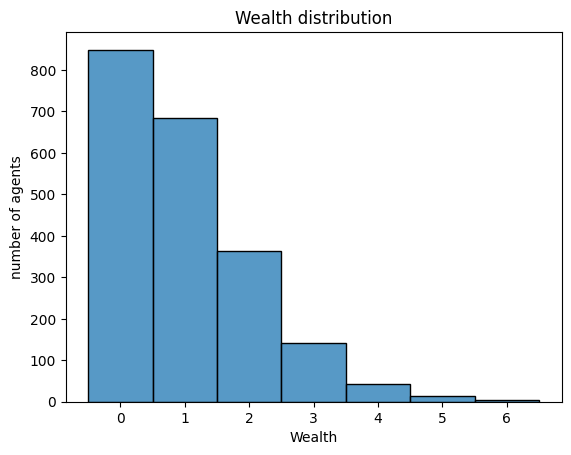

In [410]:
# Lets make sure the model works
model = MoneyModel(100, 10, 10)
model.run_for(20)


data = model.datacollector.get_agent_vars_dataframe()
# Use seaborn
g = sns.histplot(data["Wealth"], discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");